# Analisis de Correlacion por Nivel de MSI (Gold-MSI)

**Objetivo:** Entender como la experiencia musical (Gold-MSI) modula la relacion entre features jSymbolic y complejidad percibida.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

sns.set_theme(style='whitegrid')
plt.rcParams.update({'font.size': 12})

ROOT = Path('..')
ENCUESTA = ROOT / 'Encuesta'
COMP_L = ROOT / 'test4EVO' / 'ComparacionL'
COMP_H = ROOT / 'test4EVO' / 'ComparacionH'

df = pd.read_csv(ENCUESTA / '1.csv', sep=',')
score_map = {
    'A mucho m\u00e1s compleja que B': 2,
    'A m\u00e1s compleja que B': 1,
    'Igual de complejas': 0,
    'B m\u00e1s compleja que A': -1,
    'B mucho m\u00e1s compleja que A': -2
}
C_cols = [c for c in df.columns if c.startswith('C') and c != 'Correos']
L_cols = ['L1','L2','L3','L4','L5','L6']
H_cols = ['H1','H2','H3','H4','H5','H6']
all_cols = L_cols + H_cols

for col in all_cols + C_cols:
    df[col + '_score'] = df[col].map(score_map)

mask = (df['C1_score'] < 0) & (df['C2_score'] < 0)
df_f = df[mask].copy()
print(f'Participantes: {len(df)} total, {len(df_f)} pasaron control')

Participantes: 52 total, 43 pasaron control


In [2]:
rvae_files = {
    'L1': ('L1) Cmin-Gmaj-Cmin-Fmin-Cmin.mid',  'M3) Cm-Bb-Ab-Cs-Eb.mid'),
    'L2': ('L4) Cm-C7-Fm-Bb-C.mid',              'M2) Cmin-Gmaj-C7-Fmin-Cmin.mid'),
    'L3': ('L3) Cmin-Gmaj-A7-Fmaj-Cmin.mid',     'M22) Cm-Bb-Bb-Dm7-Eb.mid'),
    'L4': ('L10) Cs-Fsdim7-Fm7-Bb9-F.mid',       'M4) Cmin-Gmaj-Fs7-F7-Cmin.mid'),
    'L5': ('L5) Cmin-Emin-Emin-Fmaj-Cmin.mid',   'M1) Cm-Bb-Bb-Cm7-Fm7.mid'),
    'L6': ('L9) Abmaj7-Cmin7-Csmaj-Ebmaj.mid',   'M6) Cmin-Fsmin-A7-Dsmin-Cmin.mid'),
}
human_files = {
    'H1': ('00001REARM_OG.mid',  '00001REARM_MIO.mid'),
    'H2': ('00002REARM_OG.mid',  '00002REARM_MIO.mid'),
    'H3': ('00003REARM_OG.mid',  '00003REARM_MIO.mid'),
    'H4': ('00004REARM_OG.mid',  '00004REARM_MIO.mid'),
    'H5': ('00005REARM_OG.mid',  '00005REARM_MIO.mid'),
    'H6': ('00006REARM_OG.mid',  '00006REARM_MIO.mid'),
}
def get_labels(col):
    if col in rvae_files:
        return ('RVAE','SCL','L') if int(col[1])%2==1 else ('SCL','RVAE','L')
    else:
        return ('Humano','SCL','H') if int(col[1])%2==1 else ('SCL','Humano','H')
print("Mapping OK")

Mapping OK


In [3]:
complexity_records = []
for col in all_cols:
    sc = col + '_score'
    lab_a, lab_b, blk = get_labels(col)
    for idx in df_f.index:
        v = df_f.loc[idx, sc]
        if pd.isna(v): continue
        complexity_records.append({'p':idx,'col':col,'blk':blk,'audio':lab_a,'compl':v})
        complexity_records.append({'p':idx,'col':col,'blk':blk,'audio':lab_b,'compl':-v})
df_comp = pd.DataFrame(complexity_records)
print(f"Obs: {len(df_comp)}")

Obs: 1032


In [4]:
feature_names = [
    'Vertical_Minor_Seconds','Vertical_Tritones','Vertical_Sevenths',
    'Vertical_Dissonance_Ratio','Standard_Triads','Seventh_Chords',
    'Non-Standard_Chords','Complex_Chords',
    'Distance_Between_Two_Most_Common_Vertical_Intervals',
    'Prevalence_Ratio_of_Two_Most_Common_Vertical_Intervals',
    'Variability_of_Number_of_Simultaneous_Pitch_Classes',
]
LAB = {f:k for f,k in zip(feature_names,
    ['VMS','VT','VS','VDR','ST','7C','NSC','CC','DTMCVI','PRTMCVI','VNSPC'])}
fs = list(LAB.values())

df_L_all = pd.read_csv(COMP_L / '2.csv', index_col=0)
df_L_all.columns = df_L_all.columns.str.strip()
df_L_all.index = df_L_all.index.map(lambda x: Path(str(x).strip()).name)

df_H_all = pd.read_csv(COMP_H / 'datahvsmio_full.csv', index_col=0)
df_H_all.columns = df_H_all.columns.str.strip()
df_H_all.index = df_H_all.index.str.strip()
print(f'L: {df_L_all.shape}, H: {df_H_all.shape}')

def get_file(col, audio):
    d = rvae_files if col in rvae_files else human_files
    ref, scl = d[col]
    return scl if audio=='SCL' else ref
def get_df(col):
    return df_L_all if col in rvae_files else df_H_all

# Comp mean per audio
comp_by_audio = (df_comp.groupby(['blk','col','audio'])['compl']
    .agg(['mean','std','count','sem']).reset_index()
    .rename(columns={'mean':'compl_mean','std':'compl_std','count':'n','sem':'compl_se'}))

rows = []
for _, r in comp_by_audio.iterrows():
    f = get_file(r['col'], r['audio'])
    dfe = get_df(r['col'])
    if f not in dfe.index: continue
    fr = dfe.loc[f]
    vals = {LAB[fn]: pd.to_numeric(fr[fn], errors='coerce') for fn in feature_names}
    vals['compl'] = r['compl_mean']; vals['compl_se'] = r['compl_se']
    vals['col']=r['col']; vals['audio']=r['audio']; vals['blk']=r['blk']; vals['n']=r['n']
    rows.append(vals)

df_feats = pd.DataFrame(rows)
print(f"Audios con features: {len(df_feats)}")

L: (12, 183), H: (18, 183)
Audios con features: 24


## Distribucion de Gold-MSI

In [5]:
df_f['msi_level'] = pd.qcut(df_f['GOLD_SCORE'], q=3, labels=['Bajo', 'Medio', 'Alto'])

print("Distribucion Gold-MSI:")
print(df_f['msi_level'].value_counts().sort_index())
print()
print(f"GOLD_SCORE stats por grupo:")
print(df_f.groupby('msi_level')['GOLD_SCORE'].describe().round(1))

Distribucion Gold-MSI:
msi_level
Bajo     14
Medio    15
Alto     14
Name: count, dtype: int64

GOLD_SCORE stats por grupo:
           count  mean  std   min   25%   50%   75%   max
msi_level                                                
Bajo        14.0   4.5  3.4   0.0   2.5   4.5   5.0  12.0
Medio       15.0  20.7  4.4  13.0  18.5  20.0  24.0  27.0
Alto        14.0  37.9  7.5  28.0  31.5  37.5  42.0  51.0


/var/folders/j8/8v21hcxs2wg1v9dljnmt6sfr0000gn/T/ipykernel_83808/2128788250.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_f.groupby('msi_level')['GOLD_SCORE'].describe().round(1))


## Correlacion por nivel de MSI

In [6]:
# Reconstruir complejidad promedio por audio DENTRO de cada nivel MSI
msi_records = []
for col in all_cols:
    lab_a, lab_b, blk = get_labels(col)
    sc = col + '_score'
    for idx in df_f.index:
        v = df_f.loc[idx, sc]
        if pd.isna(v): continue
        msi = df_f.loc[idx, 'msi_level']
        msi_records.append({'msi':msi, 'col':col, 'blk':blk, 'audio':lab_a, 'compl':v})
        msi_records.append({'msi':msi, 'col':col, 'blk':blk, 'audio':lab_b, 'compl':-v})
df_msi = pd.DataFrame(msi_records)

comp_by_msi = df_msi.groupby(['msi','blk','col','audio'])['compl'].mean().reset_index()

# Merge con features
msi_feats_rows = []
for _, r in comp_by_msi.iterrows():
    f = get_file(r['col'], r['audio'])
    dfe = get_df(r['col'])
    if f not in dfe.index: continue
    fr = dfe.loc[f]
    vals = {LAB[fn]: pd.to_numeric(fr[fn], errors='coerce') for fn in feature_names}
    vals['compl'] = r['compl']
    vals['col']=r['col']; vals['audio']=r['audio']; vals['blk']=r['blk']; vals['msi']=r['msi']
    msi_feats_rows.append(vals)

df_msi_feats = pd.DataFrame(msi_feats_rows)
print(f"Total obs: {len(df_msi_feats)}")
print(df_msi_feats.groupby('msi').size())

Total obs: 72
msi
Alto     24
Bajo     24
Medio    24
dtype: int64


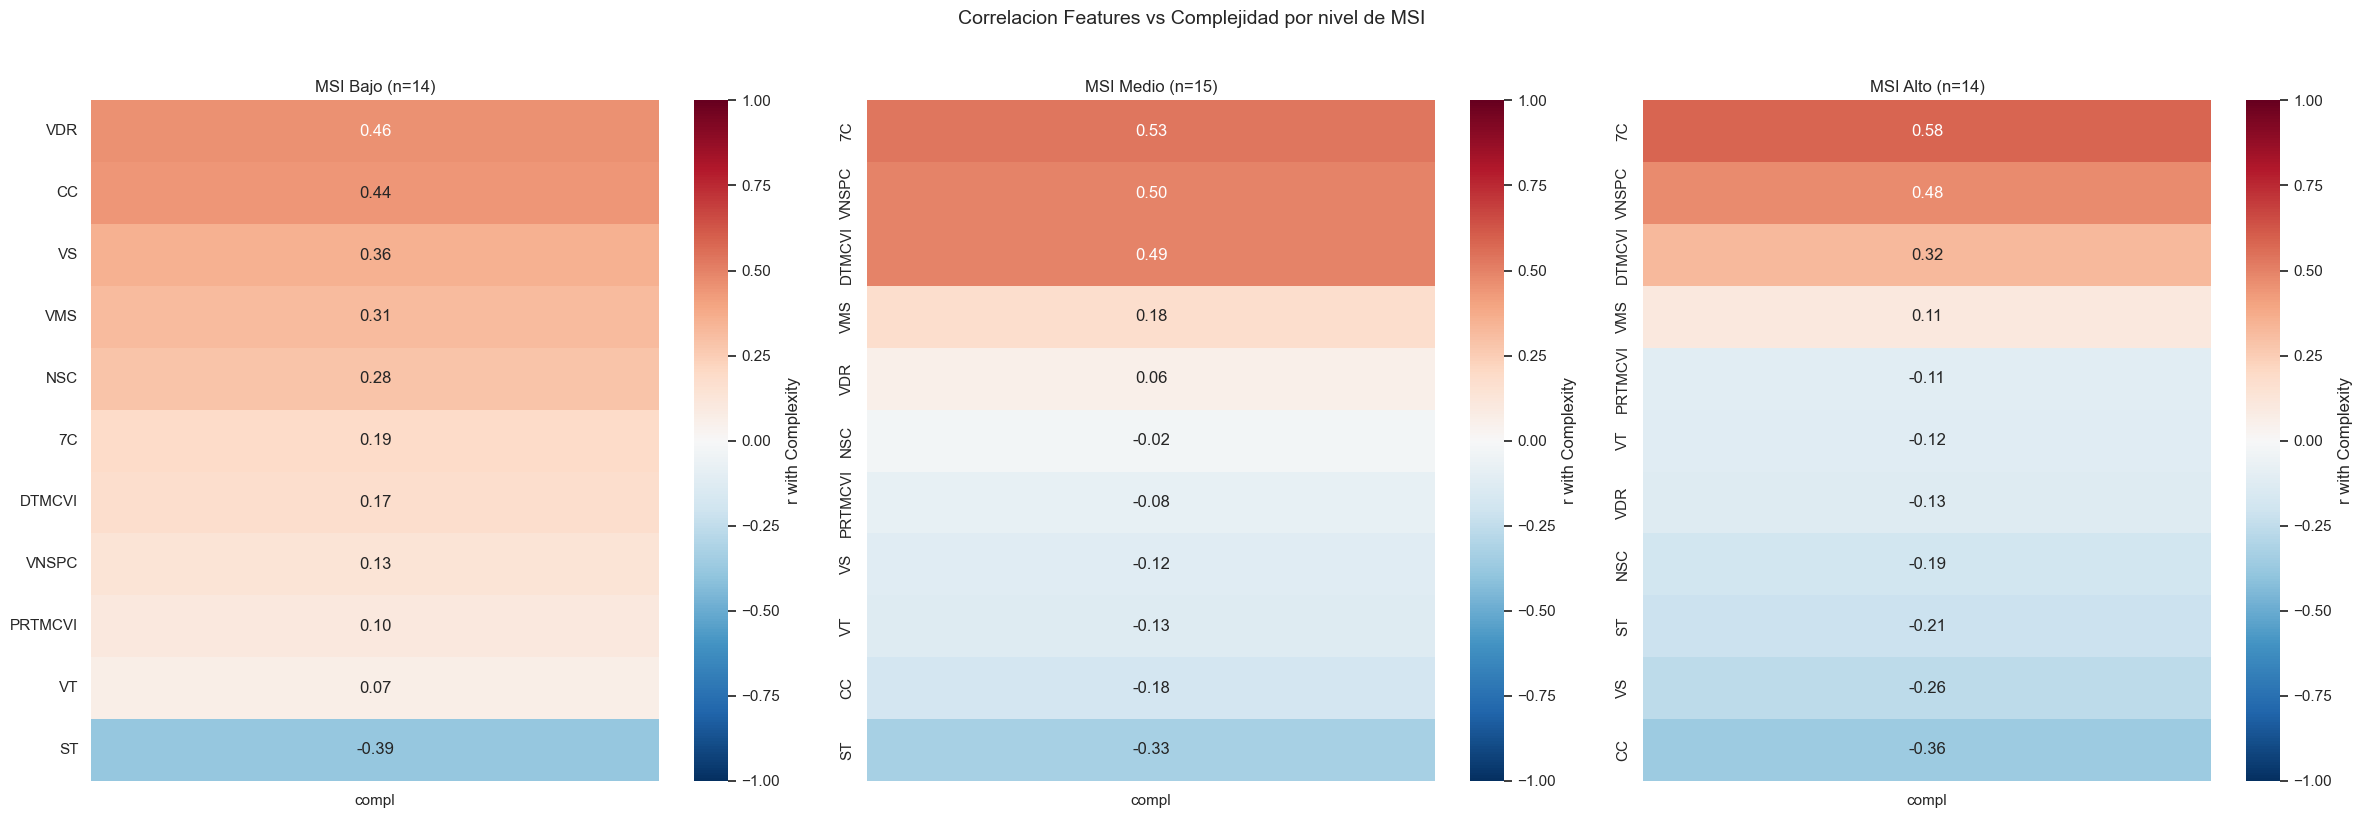

In [7]:
# Heatmap: correlacion por nivel MSI
fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for idx, msi in enumerate(['Bajo', 'Medio', 'Alto']):
    sub = df_msi_feats[df_msi_feats['msi']==msi]
    if len(sub) < 3: continue
    cm = sub[['compl']+fs].corr()
    cc = cm[['compl']].drop('compl').sort_values('compl', ascending=False)
    ax = axes[idx]
    sns.heatmap(cc, annot=True, cmap='RdBu_r', center=0, vmin=-1, vmax=1, fmt='.2f', ax=ax,
                cbar_kws={'label':'r with Complexity'})
    ax.set_title(f'MSI {msi} (n={len(df_f[df_f["msi_level"]==msi])})'); ax.set_ylabel('')
plt.suptitle('Correlacion Features vs Complejidad por nivel de MSI', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## Tabla comparativa de correlaciones por MSI

In [8]:
# Tabla correlaciones por MSI
msi_corr_rows = []
for msi in ['Bajo', 'Medio', 'Alto']:
    sub = df_msi_feats[df_msi_feats['msi']==msi]
    if len(sub) < 3: continue
    for f in fs:
        r, p = stats.pearsonr(sub[f], sub['compl'])
        msi_corr_rows.append({'MSI':msi, 'Feature':f, 'r':round(r,3), 'p':round(p,4),
                              'sig':'*' if p<.05 else 'n.s.'})

df_msi_corr = pd.DataFrame(msi_corr_rows)

# Pivot table
pivot_r = df_msi_corr.pivot(index='Feature', columns='MSI', values='r')
pivot_p = df_msi_corr.pivot(index='Feature', columns='MSI', values='p')
pivot_sig = df_msi_corr.pivot(index='Feature', columns='MSI', values='sig')

print("Correlacion (r) por nivel de MSI:")
print(pivot_r.to_string())
print()
print("Significancia:")
print(pivot_sig.to_string())
print()
print("p-value:")
print(pivot_p.to_string())

Correlacion (r) por nivel de MSI:
MSI       Alto   Bajo  Medio
Feature                     
7C       0.580  0.191  0.533
CC      -0.363  0.440 -0.184
DTMCVI   0.325  0.174  0.494
NSC     -0.189  0.283 -0.024
PRTMCVI -0.114  0.103 -0.079
ST      -0.213 -0.390 -0.334
VDR     -0.125  0.457  0.060
VMS      0.107  0.313  0.179
VNSPC    0.475  0.135  0.498
VS      -0.258  0.358 -0.119
VT      -0.119  0.068 -0.125

Significancia:
MSI      Alto  Bajo Medio
Feature                  
7C          *  n.s.     *
CC       n.s.     *  n.s.
DTMCVI   n.s.  n.s.     *
NSC      n.s.  n.s.  n.s.
PRTMCVI  n.s.  n.s.  n.s.
ST       n.s.  n.s.  n.s.
VDR      n.s.     *  n.s.
VMS      n.s.  n.s.  n.s.
VNSPC       *  n.s.     *
VS       n.s.  n.s.  n.s.
VT       n.s.  n.s.  n.s.

p-value:
MSI        Alto    Bajo   Medio
Feature                        
7C       0.0029  0.3726  0.0073
CC       0.0809  0.0316  0.3895
DTMCVI   0.1213  0.4151  0.0142
NSC      0.3753  0.1804  0.9106
PRTMCVI  0.5960  0.6315  0.7129
S

## Grafico de barras comparativo: r por MSI

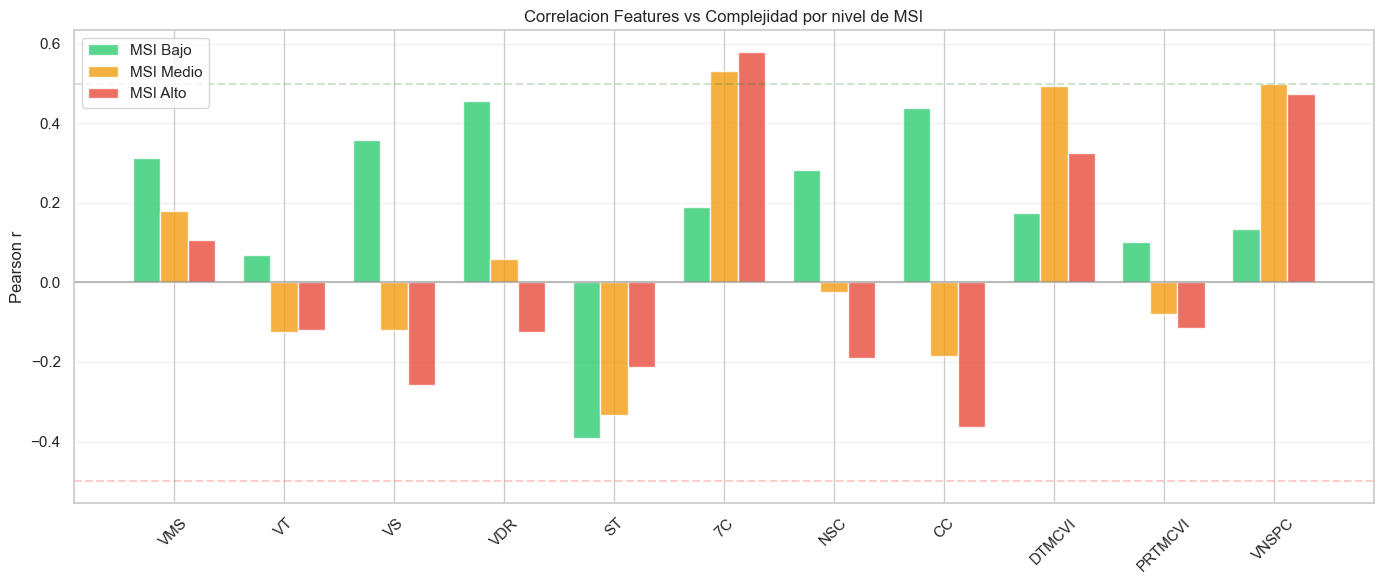

In [ ]:
# Barras agrupadas: r por feature, coloreado por MSI
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(fs))
w = 0.25
colors = {'Bajo': '#2ecc71', 'Medio': '#f39c12', 'Alto': '#e74c3c'}
for i, msi in enumerate(['Bajo', 'Medio', 'Alto']):
    vals = pivot_r[msi].reindex(fs).values
    ax.bar(x + (i-1)*w, vals, w, label=f'MSI {msi}', color=colors[msi], alpha=0.8)
ax.axhline(0, color='gray', ls='-', alpha=0.5)
ax.axhline(0.5, color='green', ls='--', alpha=0.2)
ax.axhline(-0.5, color='red', ls='--', alpha=0.2)
ax.set_xticks(x)
ax.set_xticklabels(fs, rotation=45)
ax.set_ylabel('Pearson r')
ax.set_title('Correlacion Features vs Complejidad por nivel de MSI')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

## Diferencias SCL vs Referencia por MSI

In [10]:
# Diferencia SCL - Ref por nivel MSI
msi_diff_rows = []
for msi in ['Bajo', 'Medio', 'Alto']:
    sub = df_msi_feats[df_msi_feats['msi']==msi]
    for blk, lref in [('L','RVAE'),('H','Humano')]:
        scl = sub[(sub['blk']==blk)&(sub['audio']=='SCL')]
        ref = sub[(sub['blk']==blk)&(sub['audio']==lref)]
        if len(scl)==0 or len(ref)==0: continue
        for f in fs:
            msi_diff_rows.append({'msi':msi, 'blk':blk, 'Feature':f,
                                 'SCL':round(scl[f].mean(),4),
                                 'REF':round(ref[f].mean(),4),
                                 'diff':round(scl[f].mean()-ref[f].mean(),4)})
df_msi_diff = pd.DataFrame(msi_diff_rows)

print("Diferencias SCL vs Ref por MSI:")
print(df_msi_diff.to_string(index=False))

Diferencias SCL vs Ref por MSI:
  msi blk Feature    SCL    REF    diff
 Bajo   L     VMS 0.0000 0.0000  0.0000
 Bajo   L      VT 0.0344 0.0364 -0.0020
 Bajo   L      VS 0.0595 0.0549  0.0046
 Bajo   L     VDR 0.1082 0.1180 -0.0098
 Bajo   L      ST 0.7667 0.7500  0.0167
 Bajo   L      7C 0.2333 0.1833  0.0500
 Bajo   L     NSC 0.0000 0.0667 -0.0667
 Bajo   L      CC 0.0000 0.0333 -0.0333
 Bajo   L  DTMCVI 2.0000 2.0000  0.0000
 Bajo   L PRTMCVI 0.8968 0.8611  0.0357
 Bajo   L   VNSPC 0.3634 0.3415  0.0219
 Bajo   H     VMS 0.0138 0.0000  0.0138
 Bajo   H      VT 0.0183 0.0424 -0.0240
 Bajo   H      VS 0.0043 0.1240 -0.1197
 Bajo   H     VDR 0.2360 0.3140 -0.0780
 Bajo   H      ST 0.2322 0.4375 -0.2054
 Bajo   H      7C 0.3214 0.1667  0.1548
 Bajo   H     NSC 0.4464 0.3958  0.0506
 Bajo   H      CC 0.2143 0.2500 -0.0357
 Bajo   H  DTMCVI 3.3333 2.5000  0.8333
 Bajo   H PRTMCVI 0.9185 0.8578  0.0607
 Bajo   H   VNSPC 0.4898 0.2913  0.1984
Medio   L     VMS 0.0000 0.0000  0.0000
Medio   

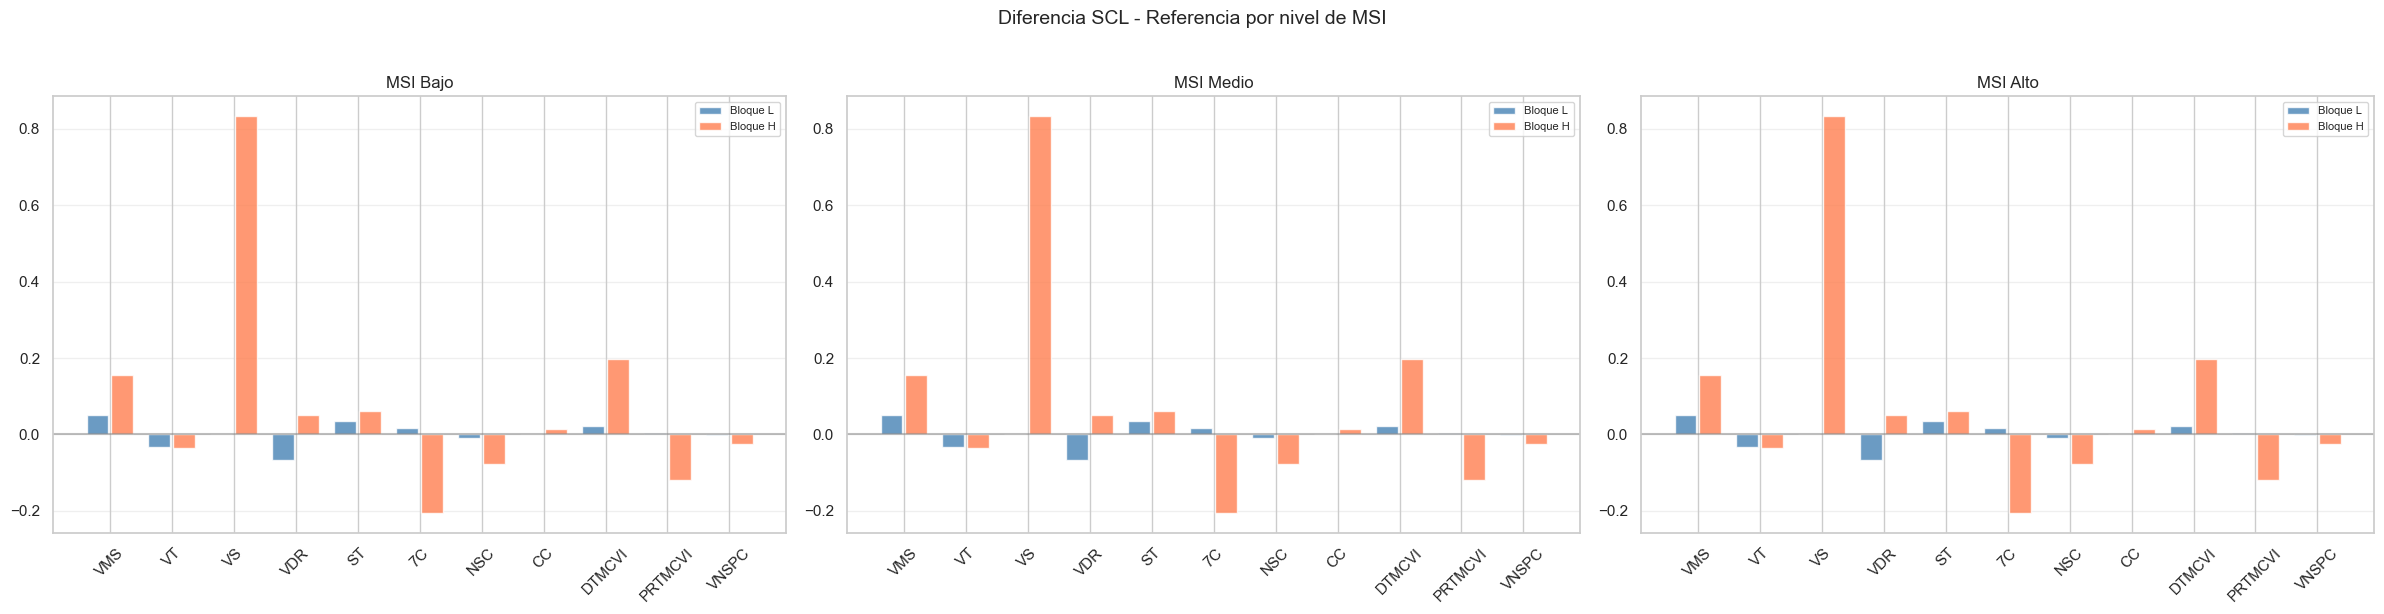

In [11]:
# Barplot diferencias SCL - Ref por MSI
fig, axes = plt.subplots(1, 3, figsize=(24, 6))
for idx, msi in enumerate(['Bajo', 'Medio', 'Alto']):
    ax = axes[idx]
    sub = df_msi_diff[df_msi_diff['msi']==msi]
    if len(sub)==0: continue
    for j, (blk, color) in enumerate([('L','steelblue'),('H','coral')]):
        s = sub[sub['blk']==blk].sort_values('Feature')
        off = -0.2 if blk=='L' else 0.2
        ax.bar(np.arange(len(fs))+off, s['diff'].values, 0.35, color=color, alpha=0.8,
               label=f'Bloque {blk}')
    ax.axhline(0, color='gray', alpha=0.5)
    ax.set_xticks(np.arange(len(fs)))
    ax.set_xticklabels(fs, rotation=45)
    ax.set_title(f'MSI {msi}')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)
plt.suptitle('Diferencia SCL - Referencia por nivel de MSI', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## Complejidad promedio por MSI

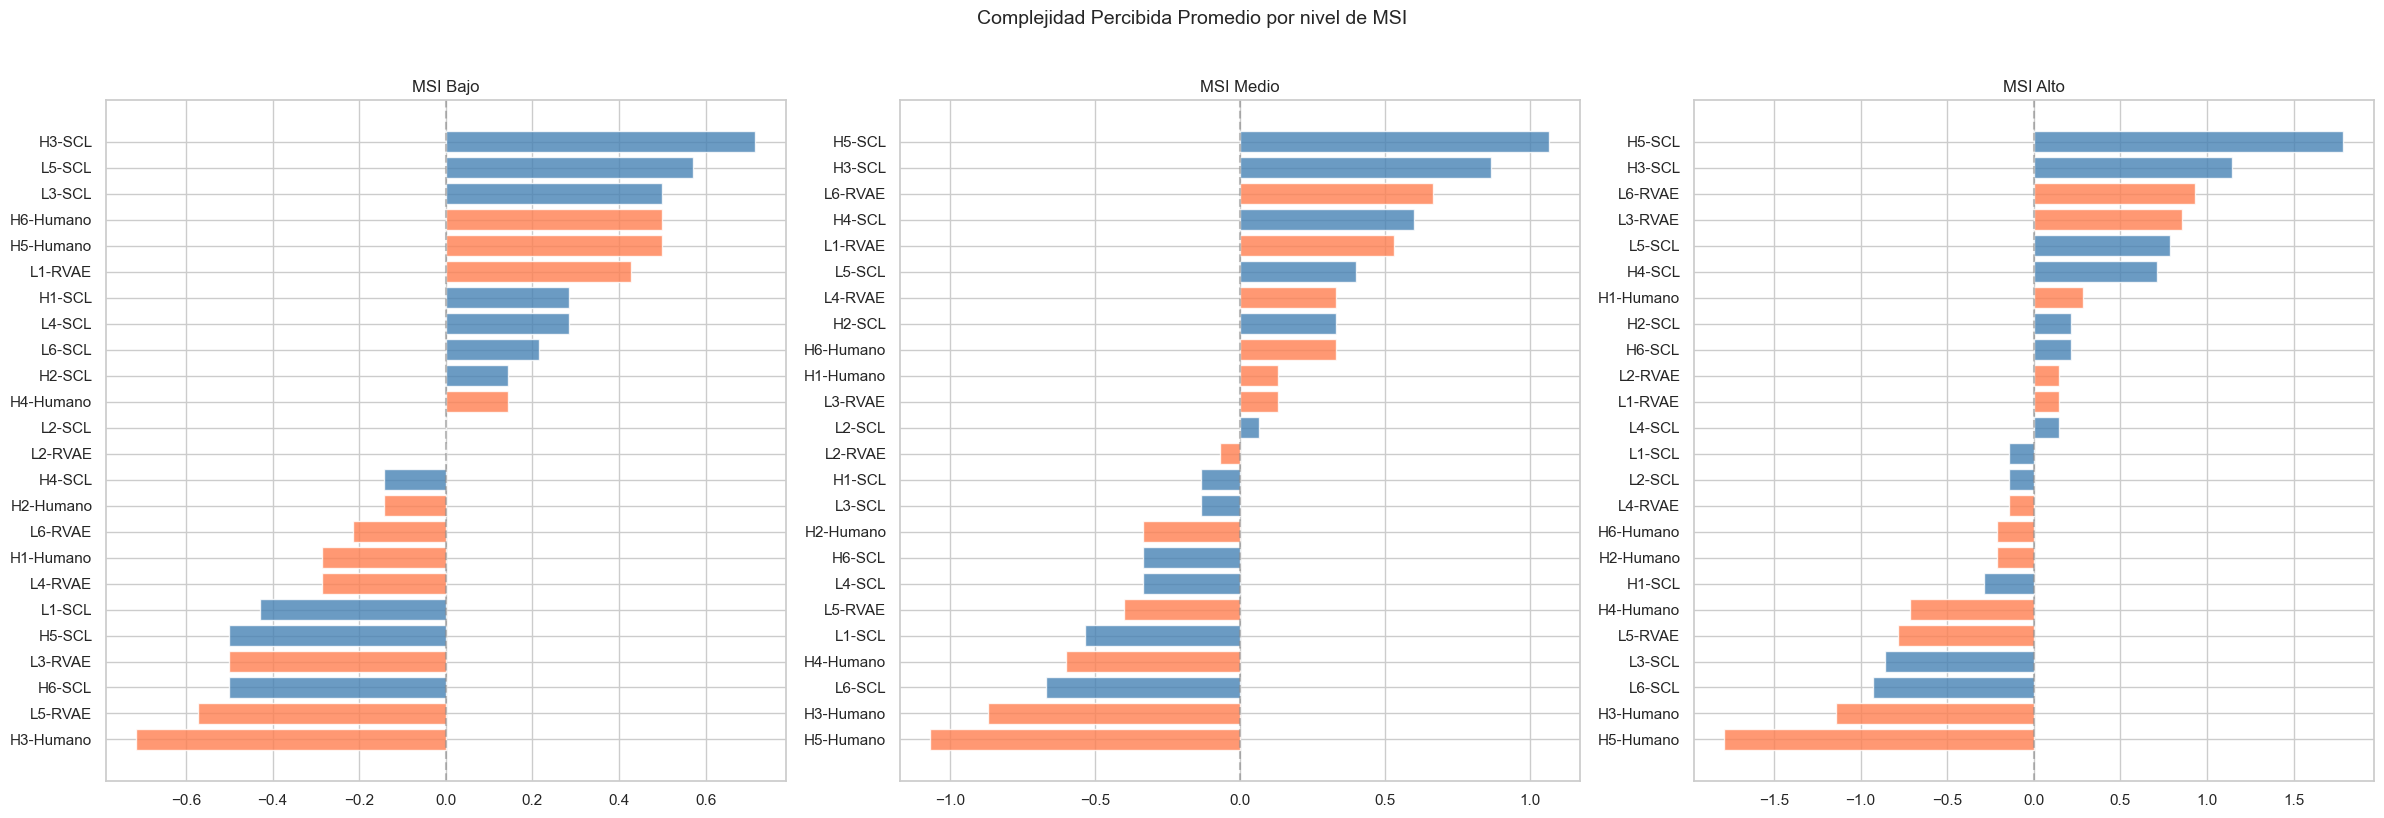

In [12]:
# Compl promedio por audio y MSI
comp_by_msi_audio = df_msi.groupby(['msi', 'col', 'audio'])['compl'].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(24, 8))
for idx, msi in enumerate(['Bajo', 'Medio', 'Alto']):
    ax = axes[idx]
    sub = comp_by_msi_audio[comp_by_msi_audio['msi']==msi].copy()
    sub['label'] = sub['col'] + '-' + sub['audio']
    sub = sub.sort_values('compl')
    colors = ['coral' if ('RVAE' in l or 'Humano' in l) else 'steelblue' for l in sub['label']]
    ax.barh(range(len(sub)), sub['compl'], color=colors, alpha=0.8)
    ax.set_yticks(range(len(sub)))
    ax.set_yticklabels(sub['label'].values)
    ax.axvline(0, color='gray', ls='--', alpha=0.5)
    ax.set_title(f'MSI {msi}')
plt.suptitle('Complejidad Percibida Promedio por nivel de MSI', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

## Hallazgos principales por MSI

In [13]:
print("="*70)
print("HALLAZGOS POR NIVEL DE MSI")
print("="*70)
print()
for msi in ['Bajo', 'Medio', 'Alto']:
    print(f"--- MSI {msi} ---")
    sub_corr = df_msi_corr[df_msi_corr['MSI']==msi].sort_values('r', ascending=False)
    sigs = sub_corr[sub_corr['sig']=='*']
    if len(sigs) > 0:
        for _, r in sigs.iterrows():
            print(f"  {r['Feature']:8s}: r={r['r']:.3f}, p={r['p']:.4f}")
    else:
        print("  Ninguna correlacion significativa")
    print()

print("-"*70)
print("Resumen de complejidad promedio por MSI:")
for msi in ['Bajo', 'Medio', 'Alto']:
    c = df_msi[df_msi['msi']==msi]['compl'].mean()
    print(f"  MSI {msi}: {c:.3f}")
print()
print("Diferencias SCL - Ref (promedio):")
for msi in ['Bajo', 'Medio', 'Alto']:
    sub = df_msi_diff[df_msi_diff['msi']==msi]
    if len(sub)==0: continue
    for blk in ['L','H']:
        s = sub[(sub['blk']==blk)]
        print(f"  MSI {msi}, Bloque {blk}: diff_avg={s['diff'].mean():.4f}")

HALLAZGOS POR NIVEL DE MSI

--- MSI Bajo ---
  VDR     : r=0.457, p=0.0249
  CC      : r=0.440, p=0.0316

--- MSI Medio ---
  7C      : r=0.533, p=0.0073
  VNSPC   : r=0.498, p=0.0133
  DTMCVI  : r=0.494, p=0.0142

--- MSI Alto ---
  7C      : r=0.580, p=0.0029
  VNSPC   : r=0.475, p=0.0189

----------------------------------------------------------------------
Resumen de complejidad promedio por MSI:
  MSI Bajo: 0.000
  MSI Medio: 0.000
  MSI Alto: 0.000

Diferencias SCL - Ref (promedio):
  MSI Bajo, Bloque L: diff_avg=0.0016
  MSI Bajo, Bloque H: diff_avg=0.0772
  MSI Medio, Bloque L: diff_avg=0.0016
  MSI Medio, Bloque H: diff_avg=0.0772
  MSI Alto, Bloque L: diff_avg=0.0016
  MSI Alto, Bloque H: diff_avg=0.0772
